Shape: (301, 9)

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-n

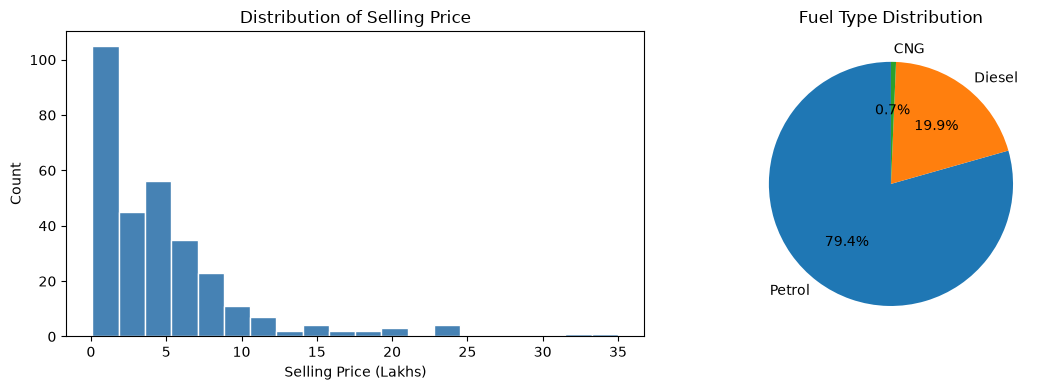

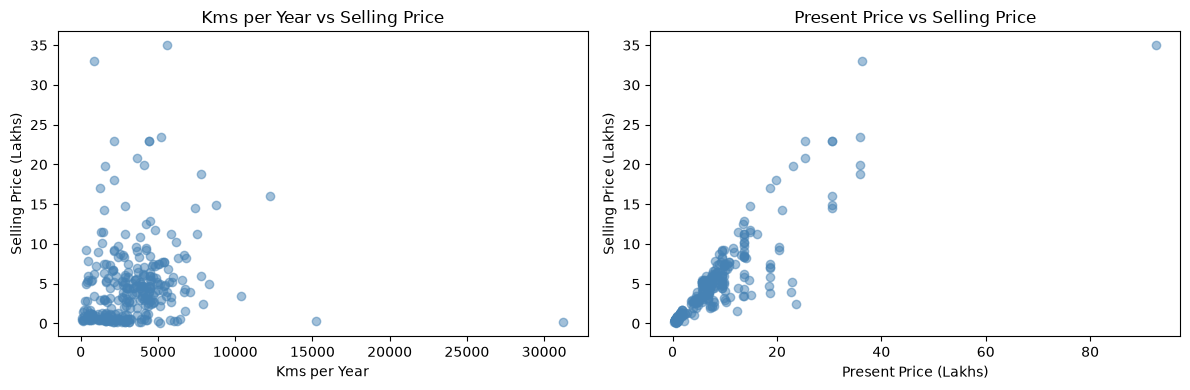


Train size: 240 | Test size: 61

Shape BEFORE pipeline: (240, 4)
Shape AFTER pipeline: (240, 8)

Model trained

RMSE : 1.851 Lakhs
R2   : 0.851


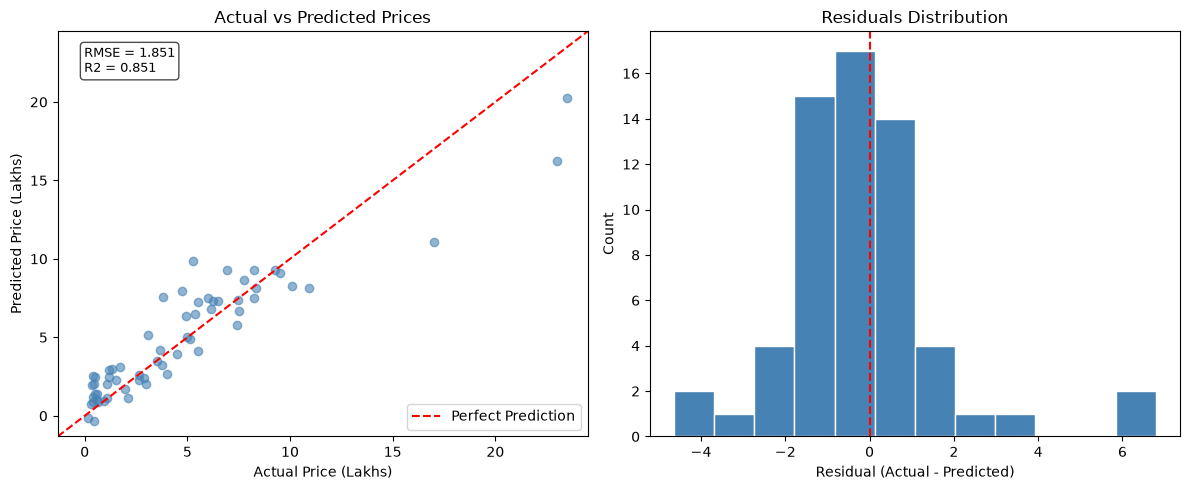

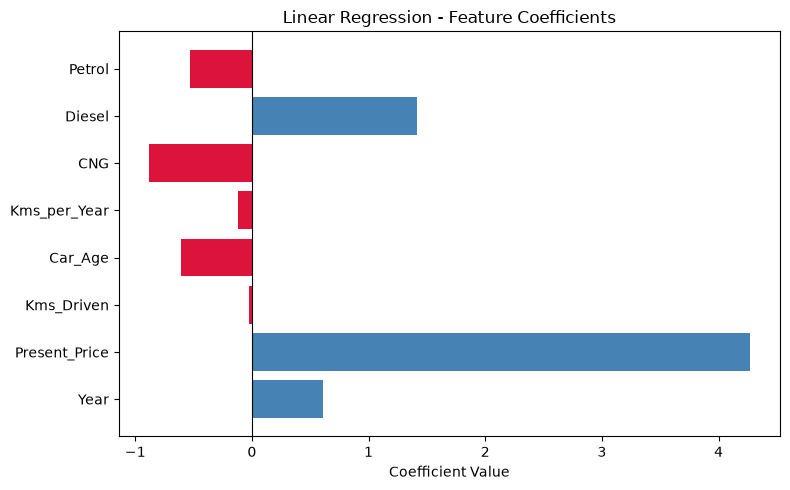


Predicted Selling Price : 8.42 Lakhs
                        (~Rs. 842,072)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("car data.csv")



print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


df["Car_Age"] = 2024 - df["Year"]

df["Car_Age"] = df["Car_Age"].replace(0, 1)

# Calculate kilometers driven per year
df["Kms_per_Year"] = df["Kms_Driven"] / df["Car_Age"]



fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(
    df["Selling_Price"],
    bins=20,
    color="steelblue",
    edgecolor="white"
)

axes[0].set_title("Distribution of Selling Price")
axes[0].set_xlabel("Selling Price (Lakhs)")
axes[0].set_ylabel("Count")


fuel_counts = df["Fuel_Type"].value_counts()

axes[1].pie(
    fuel_counts,
    labels=fuel_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Fuel Type Distribution")


plt.tight_layout()
plt.savefig("figure1_distributions.png", dpi=150)
plt.show()



fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].scatter(
    df["Kms_per_Year"],
    df["Selling_Price"],
    alpha=0.5,
    color="steelblue"
)

axes[0].set_title("Kms per Year vs Selling Price")
axes[0].set_xlabel("Kms per Year")
axes[0].set_ylabel("Selling Price (Lakhs)")


axes[1].scatter(
    df["Present_Price"],
    df["Selling_Price"],
    alpha=0.5,
    color="steelblue"
)

axes[1].set_title("Present Price vs Selling Price")
axes[1].set_xlabel("Present Price (Lakhs)")
axes[1].set_ylabel("Selling Price (Lakhs)")


plt.tight_layout()
plt.savefig("figure2_scatter.png", dpi=150)
plt.show()


df.drop(
    columns=["Car_Age", "Kms_per_Year"],
    inplace=True
)



X = df[
    [
        "Year",
        "Present_Price",
        "Kms_Driven",
        "Fuel_Type"
    ]
].copy()

y = df["Selling_Price"].copy()



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    f"\nTrain size: {X_train.shape[0]} | "
    f"Test size: {X_test.shape[0]}"
)


class CarAttributesAdder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        # Make a copy so the original data is not modified
        X = X.copy()

        # Calculate car age
        car_age = 2024 - X["Year"]

        # Avoid division by zero
        car_age = car_age.replace(0, 1)

        # Add new features
        X["Car_Age"] = car_age
        X["Kms_per_Year"] = X["Kms_Driven"] / car_age

        return X



numeric_features = [
    "Year",
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Kms_per_Year"
]

categorical_features = [
    "Fuel_Type"
]


num_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])



preprocessor = ColumnTransformer([
    (
        "num",
        num_pipeline,
        numeric_features
    ),
    (
        "cat",
        OneHotEncoder(),
        categorical_features
    )
])



full_pipeline = Pipeline([
    (
        "feature_engineering",
        CarAttributesAdder()
    ),
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LinearRegression()
    )
])



prep_only = Pipeline([
    (
        "feature_engineering",
        CarAttributesAdder()
    ),
    (
        "preprocessor",
        preprocessor
    )
])

X_train_transformed = prep_only.fit_transform(X_train)

print(f"\nShape BEFORE pipeline: {X_train.shape}")
print(f"Shape AFTER pipeline: {X_train_transformed.shape}")



full_pipeline.fit(
    X_train,
    y_train
)

print("\nModel trained")



y_pred = full_pipeline.predict(X_test)



rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"\nRMSE : {rmse:.3f} Lakhs")
print(f"R2   : {r2:.3f}")



residuals = y_test.values - y_pred

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6,
    color="steelblue"
)

lims = [
    min(y_test.min(), y_pred.min()) - 1,
    max(y_test.max(), y_pred.max()) + 1
]

axes[0].plot(
    lims,
    lims,
    "r--",
    linewidth=1.5,
    label="Perfect Prediction"
)

axes[0].set_xlim(lims)
axes[0].set_ylim(lims)

axes[0].set_xlabel("Actual Price (Lakhs)")
axes[0].set_ylabel("Predicted Price (Lakhs)")
axes[0].set_title("Actual vs Predicted Prices")

axes[0].legend()

axes[0].text(
    0.05,
    0.90,
    f"RMSE = {rmse:.3f}\nR2 = {r2:.3f}",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.7
    )
)


axes[1].hist(
    residuals,
    bins=12,
    color="steelblue",
    edgecolor="white"
)

axes[1].axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1.5
)

axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals Distribution")


plt.tight_layout()
plt.savefig(
    "figure3_evaluation.png",
    dpi=150
)

plt.show()



model = full_pipeline.named_steps["model"]


cat_names = list(
    full_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .categories_[0]
)


coef_names = numeric_features + cat_names


coef_values = model.coef_


colors = [
    "steelblue" if c >= 0 else "crimson"
    for c in coef_values
]


plt.figure(figsize=(8, 5))

plt.barh(
    coef_names,
    coef_values,
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlabel("Coefficient Value")
plt.title(
    "Linear Regression - Feature Coefficients"
)

plt.tight_layout()

plt.savefig(
    "figure4_coefficients.png",
    dpi=150
)

plt.show()




new_car = pd.DataFrame([
    {
        "Year": 2018,
        "Present_Price": 8.5,
        "Kms_Driven": 35000,
        "Fuel_Type": "Diesel"
    }
])


predicted_price = full_pipeline.predict(
    new_car
)[0]


print(
    f"\nPredicted Selling Price : "
    f"{predicted_price:.2f} Lakhs"
)

print(
    f"                        "
    f"(~Rs. {predicted_price * 100000:,.0f})"
)